# Maximum diversification: optimize the diversification ratio

A high diversification ratio and low portfolio variance are different objectives. This notebook compares their implied weights using an original constructed covariance matrix, without claiming market performance.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/allocation.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.figsize': (9, 4.8), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18})

## One covariance, four portfolio rules

Annual volatilities are assumptions. All portfolios are long-only and fully invested; no expected returns, borrowing or transaction costs enter this static illustration.

In [2]:
from research.allocation import inverse_vol, erc
names = ['Equities', 'Long bonds', 'Diversifier']
vol = np.array([.18,.08,.12])
corr = np.array([[1,.20,.05],[.20,1,.15],[.05,.15,1]])
cov = np.outer(vol,vol)*corr
assert np.linalg.eigvalsh(cov).min()>0

def diversification(w):
    return (w @ vol)/np.sqrt(w @ cov @ w)

def optimize(objective):
    fit = minimize(objective,np.full(3,1/3),method='SLSQP',bounds=[(0,1)]*3,
                   constraints=[{'type':'eq','fun':lambda w:w.sum()-1}],options={'ftol':1e-12,'maxiter':1000})
    assert fit.success,fit.message
    assert abs(fit.x.sum()-1)<1e-8 and fit.x.min()>-1e-8
    return fit.x

weights = pd.DataFrame({'Maximum diversification':optimize(lambda w:-diversification(w)),
                        'Minimum variance':optimize(lambda w:w @ cov @ w),
                        'Inverse volatility':inverse_vol(cov),'ERC':erc(cov)},index=names)
summary = pd.DataFrame([{'Rule':name,'Diversification ratio':diversification(w.to_numpy()),
                        'Annual volatility':np.sqrt(w.to_numpy() @ cov @ w.to_numpy()),
                        'Concentration sum(w²)':np.square(w).sum()} for name,w in weights.items()]).set_index('Rule')
display(summary.round(6))

,Diversification ratio,Annual volatility,Concentration sum(w²)
Rule,,,
Maximum diversification,1.541882,0.075213,0.355918
Minimum variance,1.422024,0.069366,0.506015
Inverse volatility,1.538968,0.073870,0.368421
ERC,1.540785,0.074323,0.363163


## The resulting exposures

The diversification objective rewards how risks combine; the minimum-variance objective can favor the lowest standalone risk. Equal risk contribution balances a different quantity again.

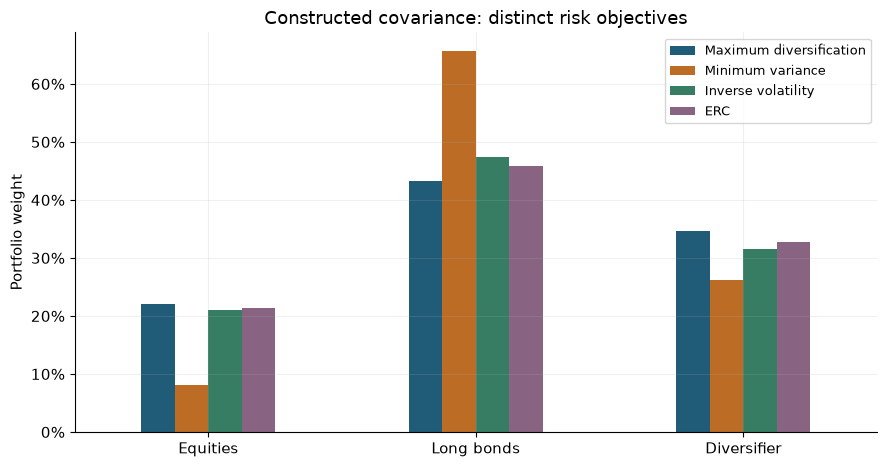

,Maximum diversification,Minimum variance,Inverse volatility,ERC
Equities,22.10%,8.14%,21.05%,21.40%
Long bonds,43.23%,65.61%,47.37%,45.80%
Diversifier,34.67%,26.24%,31.58%,32.80%


In [3]:
ax = weights.plot.bar(rot=0,color=['#205b78','#bc6c25','#367d63','#886482'])
ax.set(ylabel='Portfolio weight',title='Constructed covariance: distinct risk objectives')
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
display(weights.style.format('{:.2%}'))

## Independent solution and limiting case

When the interior direction $\Sigma^{-1}\sigma$ is nonnegative, its normalized vector supplies an independent solution. Three equal-volatility independent assets at equal weight have diversification ratio $\sqrt3$.

In [4]:
interior = np.linalg.solve(cov,vol); interior /= interior.sum()
assert interior.min()>0
np.testing.assert_allclose(weights['Maximum diversification'],interior,atol=2e-6)
equal = np.full(3,1/3); identical_vol=np.full(3,.10)
independent_cov=np.diag(identical_vol**2)
known_ratio=(equal @ identical_vol)/np.sqrt(equal @ independent_cov @ equal)
np.testing.assert_allclose(known_ratio,np.sqrt(3),atol=1e-12)
perfect_corr=np.outer(identical_vol,identical_vol)
np.testing.assert_allclose((equal @ identical_vol)/np.sqrt(equal @ perfect_corr @ equal),1)
assert summary.loc['Maximum diversification','Diversification ratio']>=summary['Diversification ratio'].max()-1e-8
print('Interior solution, independent-assets limit, perfect-correlation limit and budgets: passed.')

Interior solution, independent-assets limit, perfect-correlation limit and budgets: passed.


## Interpretation

A larger ratio describes the constructed covariance and feasible set. It does not establish a return premium or reliable protection when correlations change. The [research note](README.md) connects the objective to its source and to a properly designed future comparison.